In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Tùy chỉnh kích thước biểu đồ mặc định cho dễ nhìn
plt.rcParams['figure.figsize'] = (10, 6)

PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

> Thêm khối trích dẫn



--- 10 dòng dữ liệu đầu tiên ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



--- Thống kê dữ liệu thiếu ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


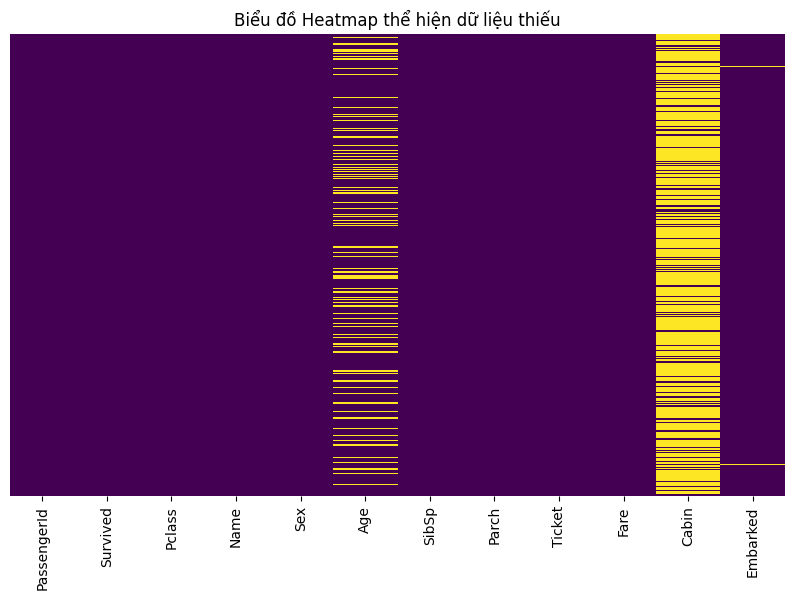

In [3]:
# 1. Viết hàm load_data() và hiển thị 10 dòng đầu
def load_data(file_path):
    return pd.read_csv(file_path)

# Giả sử file dữ liệu của bạn tên là 'train.csv'
df = load_data('titanic_disaster.csv')
print("--- 10 dòng dữ liệu đầu tiên ---")
display(df.head(10)) # Dùng display() trong Jupyter Notebook sẽ đẹp hơn print()

# 2. Thống kê và trực quan hóa dữ liệu thiếu
print("\n--- Thống kê dữ liệu thiếu ---")
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Biểu đồ Heatmap thể hiện dữ liệu thiếu')
plt.show()

/tmp/ipykernel_429/2523201556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')


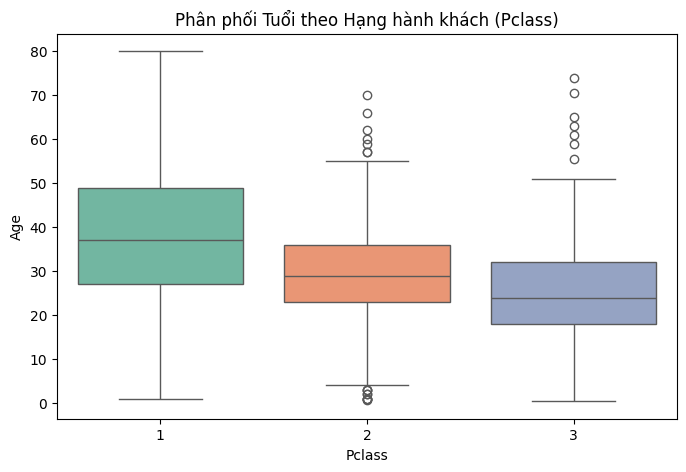

In [4]:
# 3. Xử lý tên cột Name, tách làm 2 cột firstName và secondName, sau đó xóa cột Name
# Cấu trúc tên Titanic thường là "Họ, Danh xưng. Tên". Ta sẽ tách bằng dấu phẩy.
df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)
df.drop('Name', axis=1, inplace=True)

# 4. Rút gọn kích thước dữ liệu trên cột Sex: male -> M, female -> F
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})

# 5a. Sử dụng Seaborn vẽ Box plot xác định phân phối tuổi trên từng hạng hành khách
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title('Phân phối Tuổi theo Hạng hành khách (Pclass)')
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\.'
<>:25: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_429/1051976601.py:25: SyntaxWarning: invalid escape sequence '\.'
  df['namePrefix'] = df['secondName'].str.extract(' ([A-Za-z]+)\.', expand=False)


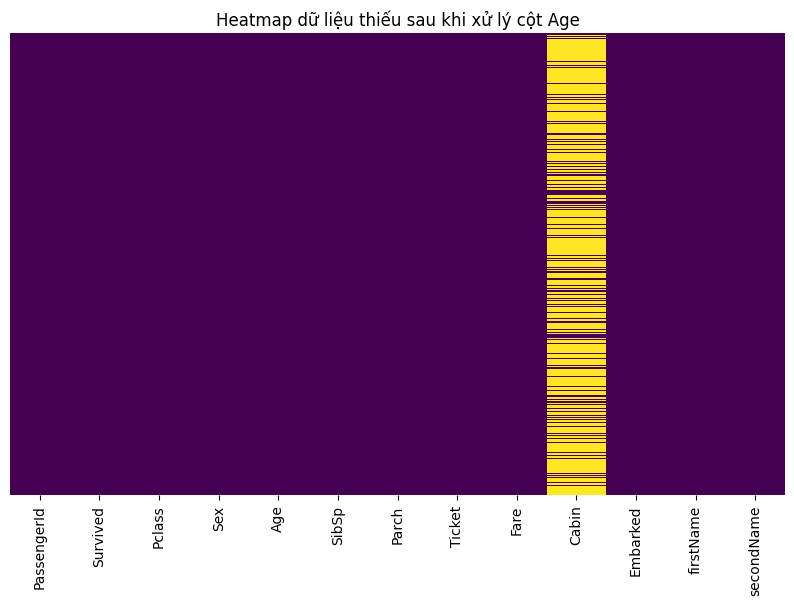

In [5]:
# 5b. Tiến hành thay thế giá trị Age bị thiếu theo trung bình của từng Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))

# Trực quan lại Heatmap sau khi xử lý Age
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Heatmap dữ liệu thiếu sau khi xử lý cột Age')
plt.show()

# 6. Xây dựng biến Agegroup
def categorize_age(age):
    if age <= 12:
        return 'Kid'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Older'

df['Agegroup'] = df['Age'].apply(categorize_age)

# 7. Tách danh xưng (namePrefix) từ cột secondName
# Các danh xưng thường đứng ngay sau dấu phẩy và kết thúc bằng dấu chấm (VD: " Mr.", " Mrs.")
df['namePrefix'] = df['secondName'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 8. Khai thác familySize = 1 + SibSp + Parch
df['familySize'] = 1 + df['SibSp'] + df['Parch']

# 9. Tạo đặc trưng 'Alone'
# Lưu ý đề bài: Nếu dùng công thức (1 + SibSp + Parch), người đi 1 mình sẽ có familySize = 1.
# Đề ghi "nếu familySize = 0 thì Alone = 1" có thể là một nhầm lẫn nhỏ của đề.
# Căn cứ vào logic thực tế, mình sẽ set Alone = 1 khi familySize == 1.
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)

# 10. Tách loại cabin (typeCabin)
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].apply(lambda x: x[0]) # Lấy chữ cái đầu tiên

# 11. Loại bỏ dữ liệu thừa (nếu bạn load cả tập test, hãy gộp lại và dùng hàm drop_duplicates)
# Ví dụ minh họa nếu có tập test:
# df_test = load_data('test.csv')
# df_all = pd.concat([df, df_test])
# df_all.drop_duplicates(subset=['PassengerId'], keep='first', inplace=True)
# Tuy nhiên, đối với bài Lab này nếu chỉ làm trên train.csv, bước này có thể bỏ qua hoặc giữ code dưới dạng phòng hờ:
df.drop_duplicates(subset=['PassengerId'], keep='first', inplace=True)

KHAI THÁC THÔNG TIN HỮU ÍCH_EDA

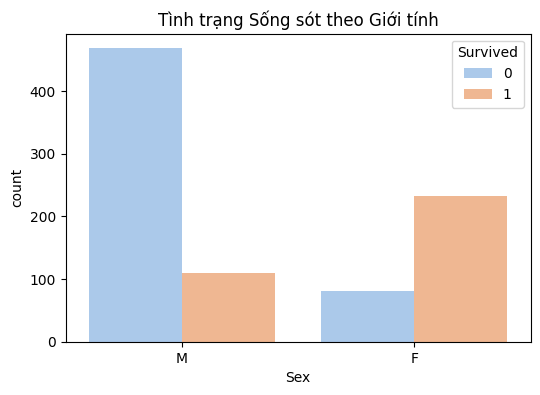

In [6]:
# 12. Trực quan thông tin tương quan tỉ lệ sống sót trên nhóm giới tính
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='pastel')
plt.title('Tình trạng Sống sót theo Giới tính')
plt.show()

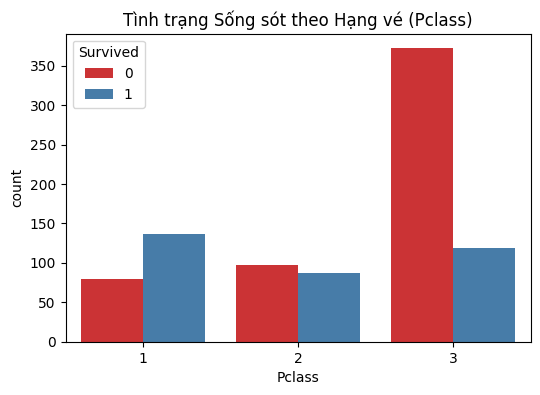

In [7]:
# 13. Trực quan thông tin sống sót trên từng nhóm phân loại hành khách (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set1')
plt.title('Tình trạng Sống sót theo Hạng vé (Pclass)')
plt.show()

<Figure size 1000x500 with 0 Axes>

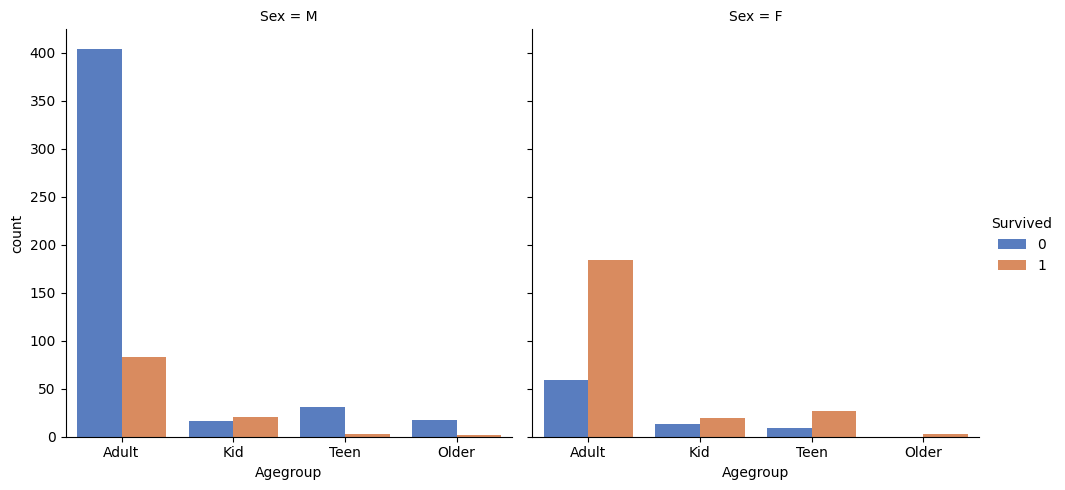

In [8]:
# 14. Trực quan sống sót trên nhóm giới tính và thang đo tuổi tác (Agegroup)
plt.figure(figsize=(10, 5))
sns.catplot(x='Agegroup', hue='Survived', col='Sex', data=df, kind='count', palette='muted')
plt.show()

/tmp/ipykernel_429/3668381641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='familySize', y='Survived', data=df, palette='coolwarm')


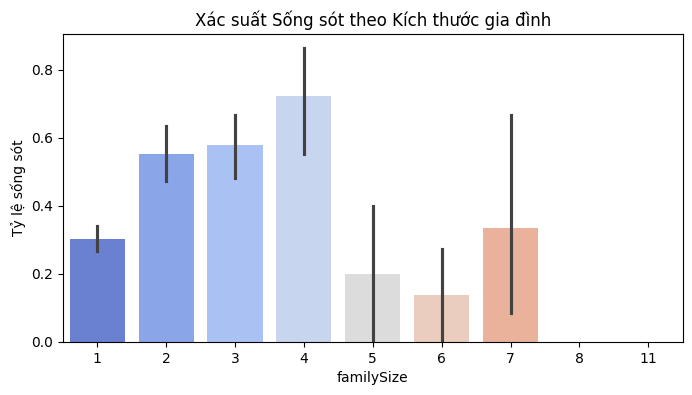

In [9]:
# 15. Trực quan xác suất sống sót dựa trên thông tin nhóm đi cùng (familySize)
plt.figure(figsize=(8, 4))
sns.barplot(x='familySize', y='Survived', data=df, palette='coolwarm')
plt.title('Xác suất Sống sót theo Kích thước gia đình')
plt.ylabel('Tỷ lệ sống sót')
plt.show()

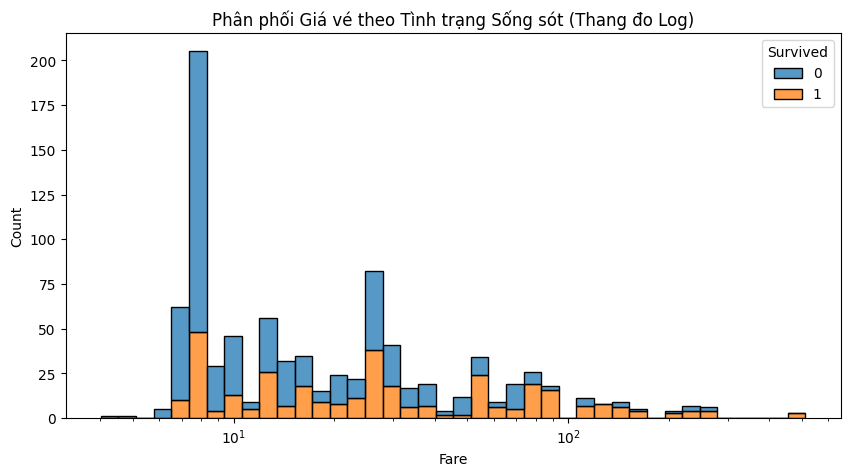

In [10]:
# 16. Trực quan xác suất sống sót dựa trên giá vé (Fare)
plt.figure(figsize=(10, 5))
sns.histplot(df, x='Fare', hue='Survived', multiple='stack', bins=40, log_scale=True)
plt.title('Phân phối Giá vé theo Tình trạng Sống sót (Thang đo Log)')
plt.show()

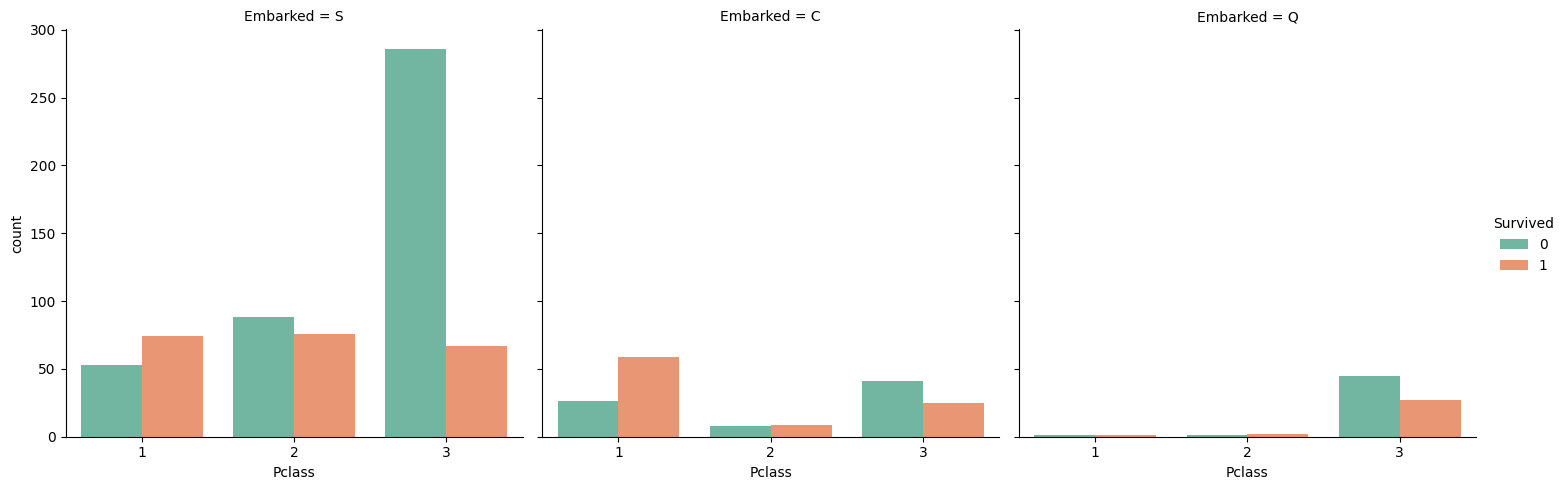

In [11]:
# 17. Trực quan thiệt mạng và sống sót theo Pclass và Cảng cập bến (Embarked)
sns.catplot(x='Pclass', hue='Survived', col='Embarked', data=df, kind='count', palette='Set2')
plt.show()